# Sector-Wise Analysis and Comparison of S\&P 500 Company Stock Prices

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [11]:
df_index = pd.read_csv("sp500_index.csv")
df_index.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2517 non-null   object 
 1   S&P500  2517 non-null   float64
dtypes: float64(1), object(1)
memory usage: 39.5+ KB


In [13]:
df_stocks = pd.read_csv("sp500_stocks.csv")
df_stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891536 entries, 0 to 1891535
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date       object 
 1   Symbol     object 
 2   Adj Close  float64
 3   Close      float64
 4   High       float64
 5   Low        float64
 6   Open       float64
 7   Volume     float64
dtypes: float64(6), object(2)
memory usage: 115.5+ MB


In [287]:
df_comp = pd.read_csv("sp500_companies.csv")
df_comp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Exchange             502 non-null    object 
 1   Symbol               502 non-null    object 
 2   Shortname            502 non-null    object 
 3   Longname             502 non-null    object 
 4   Sector               502 non-null    object 
 5   Industry             502 non-null    object 
 6   Currentprice         502 non-null    float64
 7   Marketcap            502 non-null    int64  
 8   Ebitda               473 non-null    float64
 9   Revenuegrowth        499 non-null    float64
 10  City                 502 non-null    object 
 11  State                482 non-null    object 
 12  Country              502 non-null    object 
 13  Fulltimeemployees    493 non-null    float64
 14  Longbusinesssummary  502 non-null    object 
 15  Weight               502 non-null    flo

## 1. Trend Analysis

### Index Fund CSV

In [18]:
df_index.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2517 non-null   object 
 1   S&P500  2517 non-null   float64
dtypes: float64(1), object(1)
memory usage: 39.5+ KB


In [20]:
# Convert 'Date' column to datetime
df_index['Date'] = pd.to_datetime(df_index['Date'])

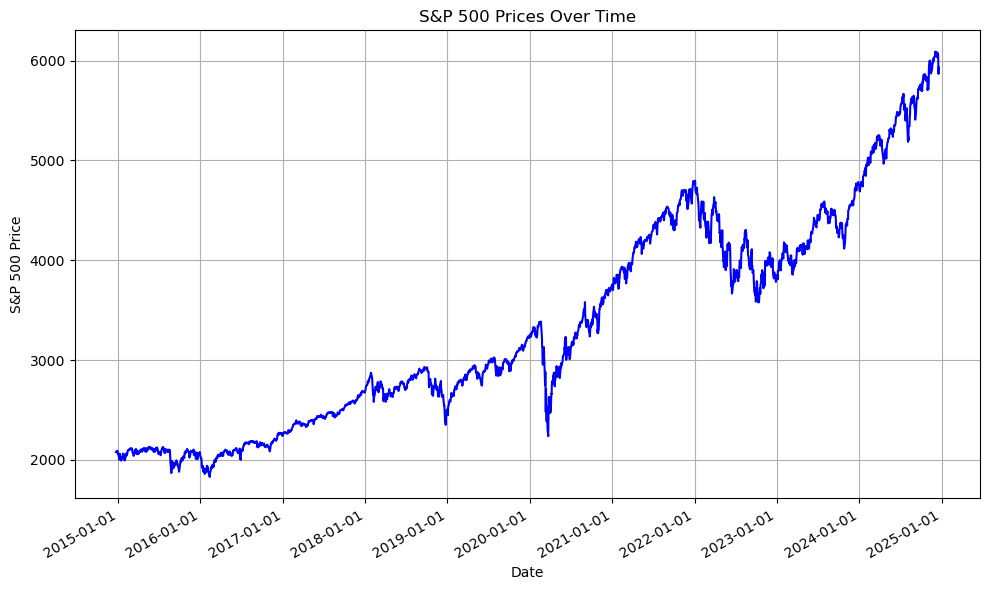

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(df_index['Date'], df_index['S&P500'], color='b')
plt.title('S&P 500 Prices Over Time')
plt.xlabel('Date')
plt.ylabel('S&P 500 Price')
plt.grid(True)

# Define the date format
date_format = mdates.DateFormatter('%Y-%m-%d')
plt.gca().xaxis.set_major_formatter(date_format)

# Auto-format date labels
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

### Companies CSV

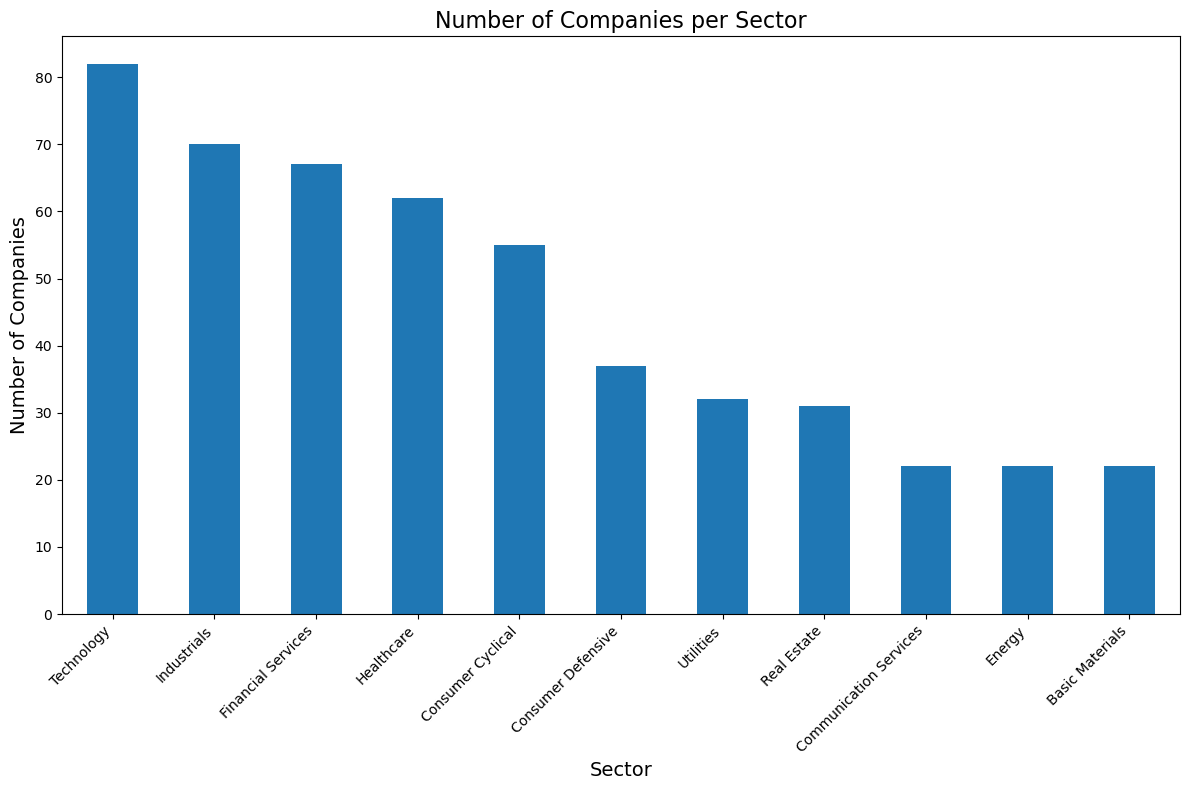

In [118]:
# Count the number of companies in each sector
sector_counts = df_comp['Sector'].value_counts()

# Plotting
plt.figure(figsize=(12, 8))  # Adjust the size as needed
sector_counts.plot(kind='bar')

plt.title('Number of Companies per Sector', fontsize=16)
plt.xlabel('Sector', fontsize=14)
plt.ylabel('Number of Companies', fontsize=14)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of labels

# Display the plot
plt.show()


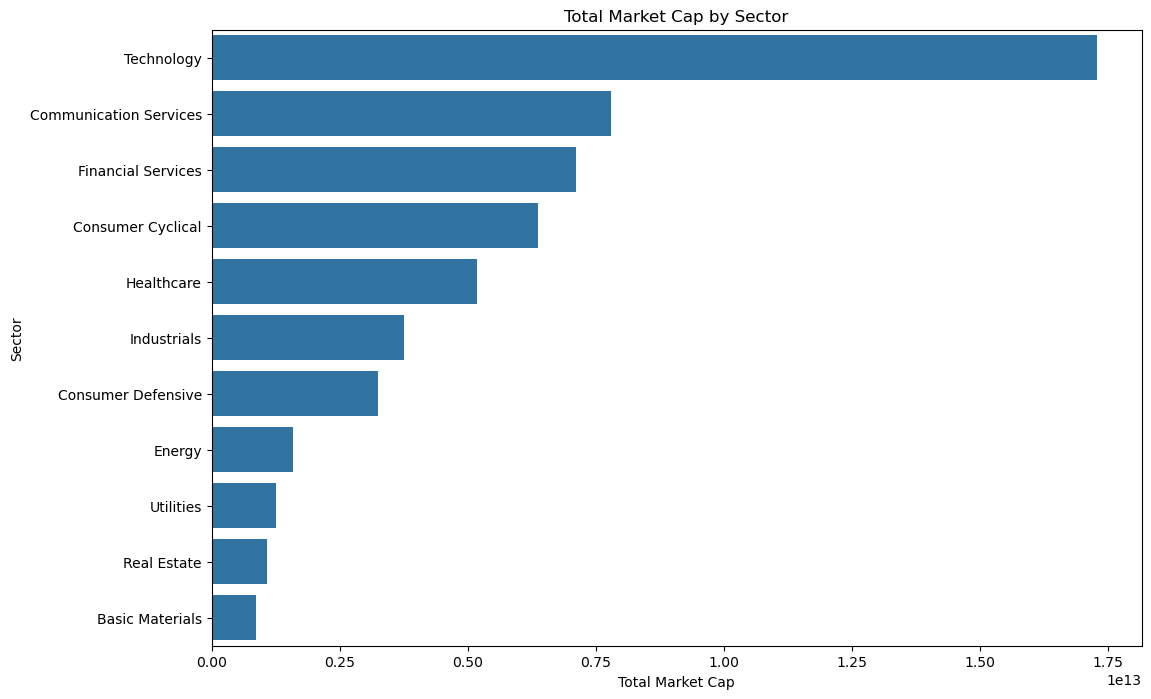

In [120]:
# Calculate the total Market Cap per Sector
sector_total_marketcap = df_comp.groupby('Sector')['Marketcap'].sum().sort_values(ascending=False)

# Set the plot size
plt.figure(figsize=(12, 8))

# Create the barplot
sns.barplot(x=sector_total_marketcap.values, y=sector_total_marketcap.index)

# Add titles and labels
plt.xlabel('Total Market Cap')
plt.ylabel('Sector')
plt.title('Total Market Cap by Sector')

# Display the plot
plt.show()

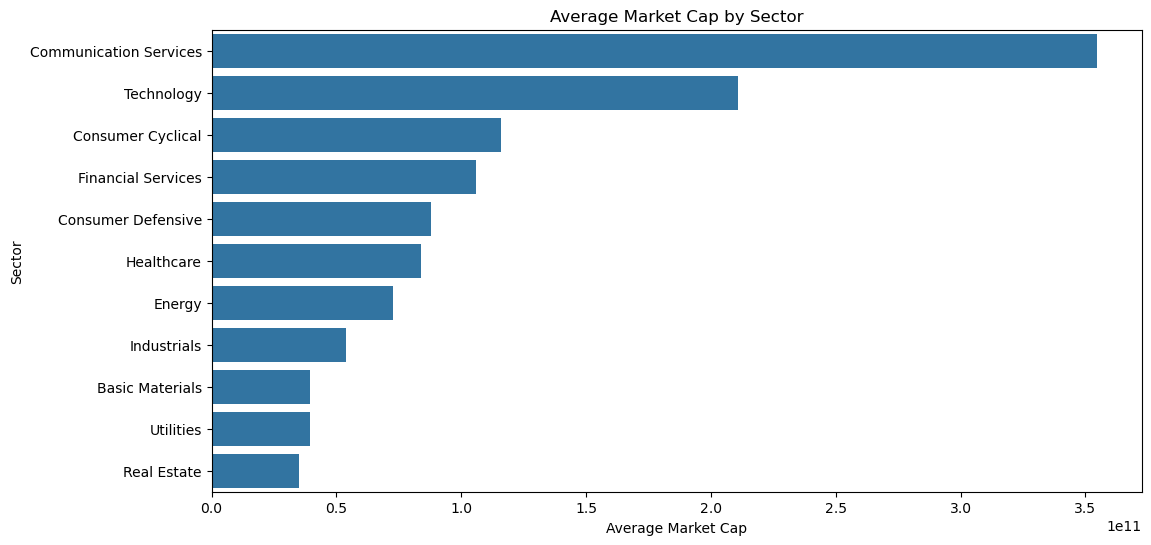

In [122]:
plt.figure(figsize=(12, 6))
sector_marketcap = df_comp.groupby('Sector')['Marketcap'].mean().sort_values(ascending=False)
sns.barplot(x=sector_marketcap.values, y=sector_marketcap.index)
plt.xlabel('Average Market Cap')
plt.ylabel('Sector')
plt.title('Average Market Cap by Sector')
plt.show()

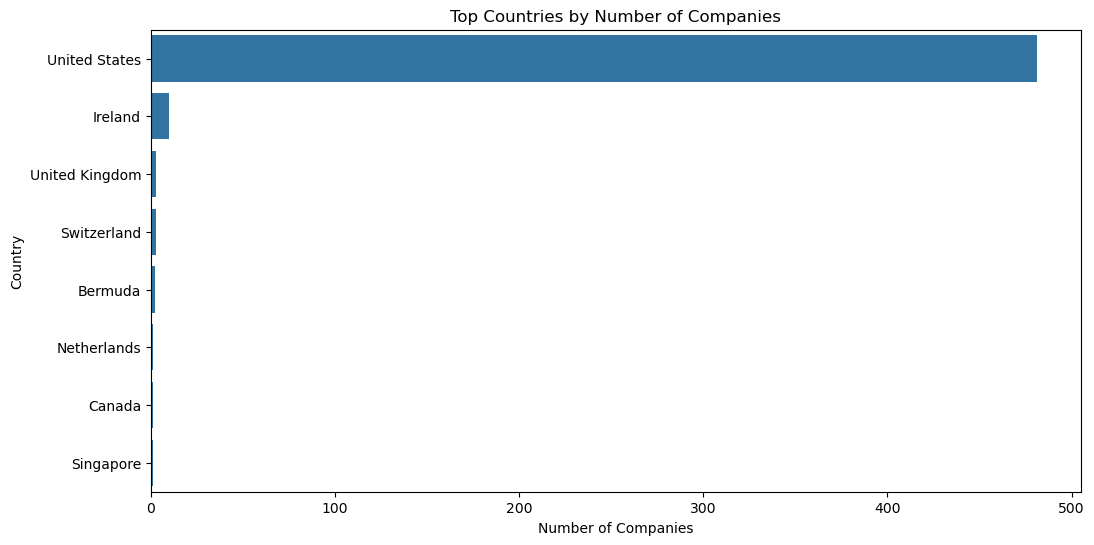

In [124]:
plt.figure(figsize=(12, 6))
country_counts = df_comp['Country'].value_counts()
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.xlabel('Number of Companies')
plt.ylabel('Country')
plt.title('Top Countries by Number of Companies')
plt.show()

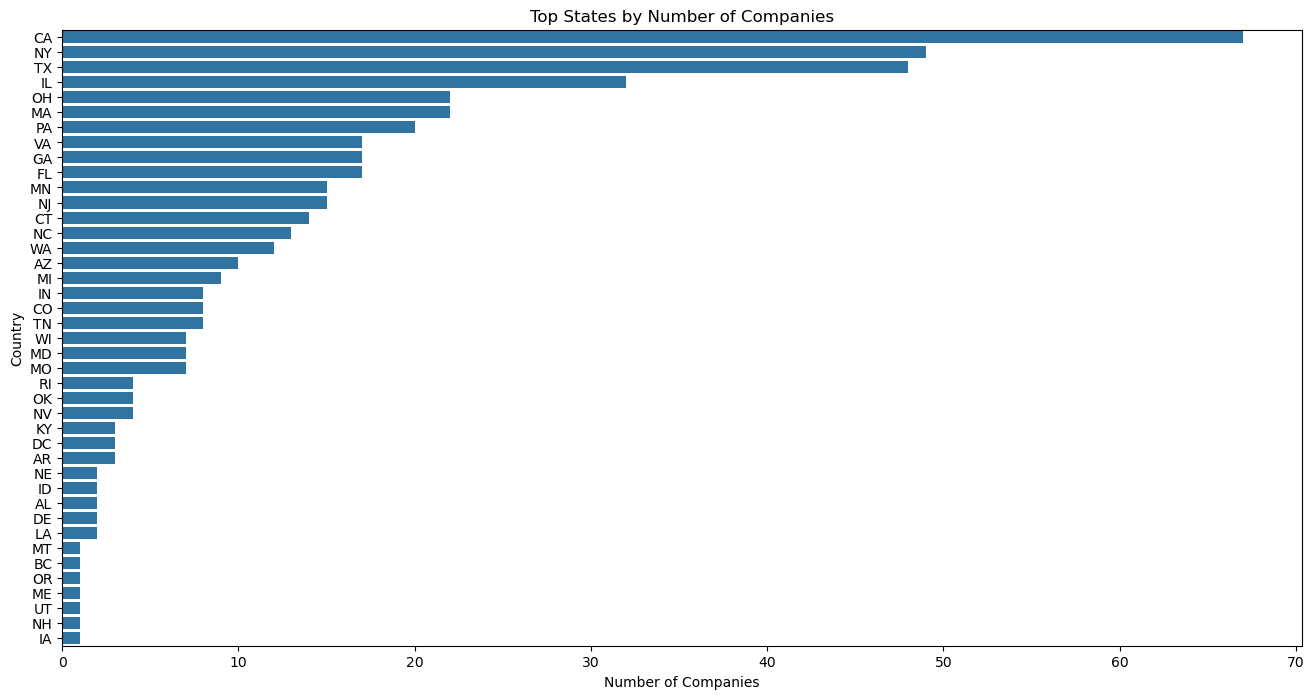

In [126]:
plt.figure(figsize=(16, 8))
country_counts = df_comp['State'].value_counts()
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.xlabel('Number of Companies')
plt.ylabel('Country')
plt.title('Top States by Number of Companies')
plt.show()

### Stocks CSV

In [129]:
# Convert date to datetime format

df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])
df_stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891536 entries, 0 to 1891535
Data columns (total 8 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Date       datetime64[ns]
 1   Symbol     object        
 2   Adj Close  float64       
 3   Close      float64       
 4   High       float64       
 5   Low        float64       
 6   Open       float64       
 7   Volume     float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 115.5+ MB


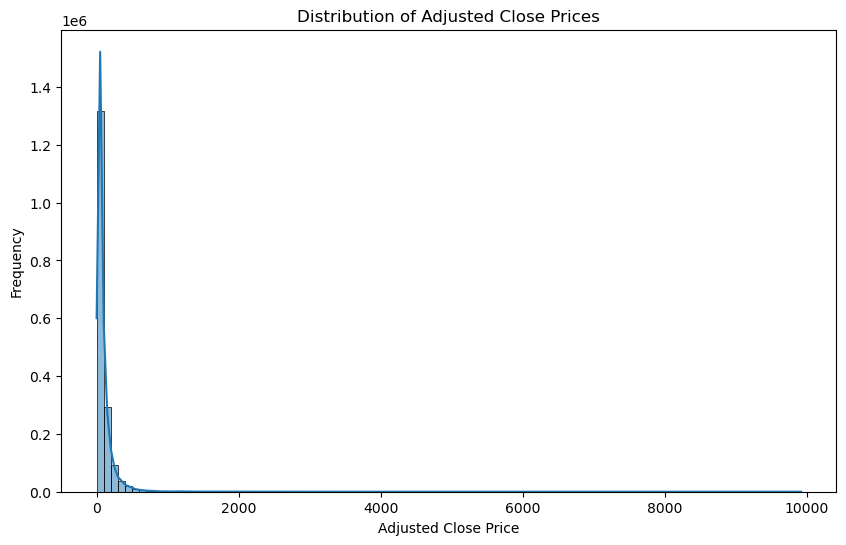

In [131]:
plt.figure(figsize=(10,6))
sns.histplot(df_stocks['Adj Close'], bins=100, kde=True)
plt.title('Distribution of Adjusted Close Prices')
plt.xlabel('Adjusted Close Price')
plt.ylabel('Frequency')
plt.show()

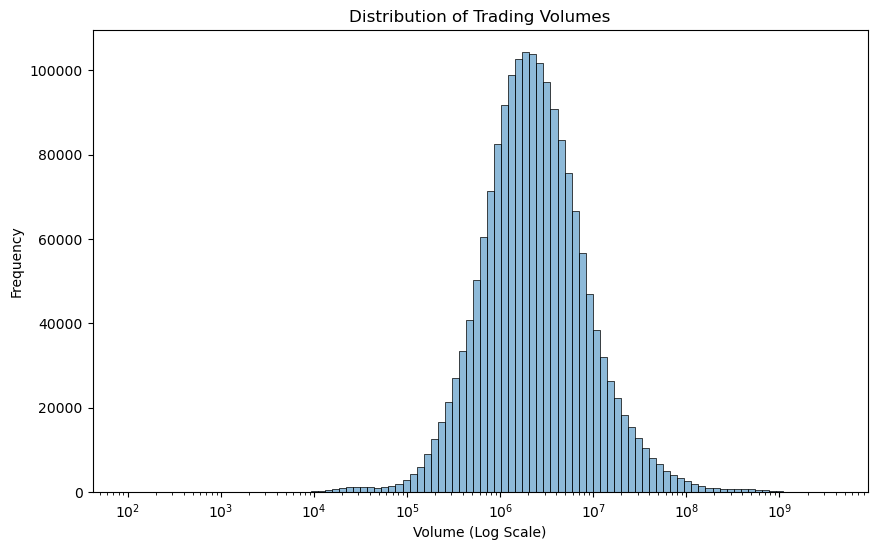

In [132]:
plt.figure(figsize=(10,6))
sns.histplot(df_stocks['Volume'], bins=100, kde=True, log_scale=True)
plt.title('Distribution of Trading Volumes')
plt.xlabel('Volume (Log Scale)')
plt.ylabel('Frequency')
plt.show()

## 2. Data Handling and Predcition

In [285]:
df_comp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Exchange             502 non-null    object 
 1   Symbol               502 non-null    object 
 2   Shortname            502 non-null    object 
 3   Longname             502 non-null    object 
 4   Sector               502 non-null    object 
 5   Industry             502 non-null    object 
 6   Currentprice         502 non-null    float64
 7   Marketcap            502 non-null    int64  
 8   Ebitda               473 non-null    float64
 9   Revenuegrowth        499 non-null    float64
 10  City                 502 non-null    object 
 11  State                482 non-null    object 
 12  Country              502 non-null    object 
 13  Fulltimeemployees    493 non-null    float64
 14  Longbusinesssummary  502 non-null    object 
 15  Weight               502 non-null    flo

In [297]:
df_comp_info = pd.DataFrame(df_comp[['Symbol','Shortname','Marketcap']])
df_comp_info['NumShares'] = df_comp['Marketcap'] / df_comp['Currentprice']
df_comp_info.head()

,Symbol,Shortname,Marketcap,NumShares
0,AAPL,Apple Inc.,3846819807232,1.511580e+10
1,NVDA,NVIDIA Corporation,3298803056640,2.449000e+10
2,MSFT,Microsoft Corporation,3246068596736,7.434880e+09
3,AMZN,"Amazon.com, Inc.",2365033807872,1.051500e+10
4,GOOGL,Alphabet Inc.,2351625142272,1.228580e+10


In [348]:
# Merge df_comp and df_stocks on the 'Symbol' column
df_merged = pd.merge(
    df_comp[['Symbol', 'Sector']], 
    df_stocks, 
    on='Symbol', 
    how='left'  # or 'left', 'right', 'outer' depending on desired merge strategy
)

# Preview the result
df_merged.head()

,Symbol,Sector,Date,Adj Close,Close,High,Low,Open,Volume
0,AAPL,Technology,2010-01-04,6.447411,7.643214,7.660714,7.585000,7.622500,493729600.0
1,AAPL,Technology,2010-01-05,6.458560,7.656429,7.699643,7.616071,7.664286,601904800.0
2,AAPL,Technology,2010-01-06,6.355828,7.534643,7.686786,7.526786,7.656429,552160000.0
3,AAPL,Technology,2010-01-07,6.344076,7.520714,7.571429,7.466071,7.562500,477131200.0
4,AAPL,Technology,2010-01-08,6.386256,7.570714,7.571429,7.466429,7.510714,447610800.0


In [350]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891536 entries, 0 to 1891535
Data columns (total 9 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Symbol     object        
 1   Sector     object        
 2   Date       datetime64[ns]
 3   Adj Close  float64       
 4   Close      float64       
 5   High       float64       
 6   Low        float64       
 7   Open       float64       
 8   Volume     float64       
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 129.9+ MB


/var/folders/db/g3_b7s9n3fvdsyb4pfxmnj200000gn/T/ipykernel_24227/3120706799.py:13: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_merged['daily_return'] = df_merged.groupby('Symbol')['Adj Close'].pct_change()


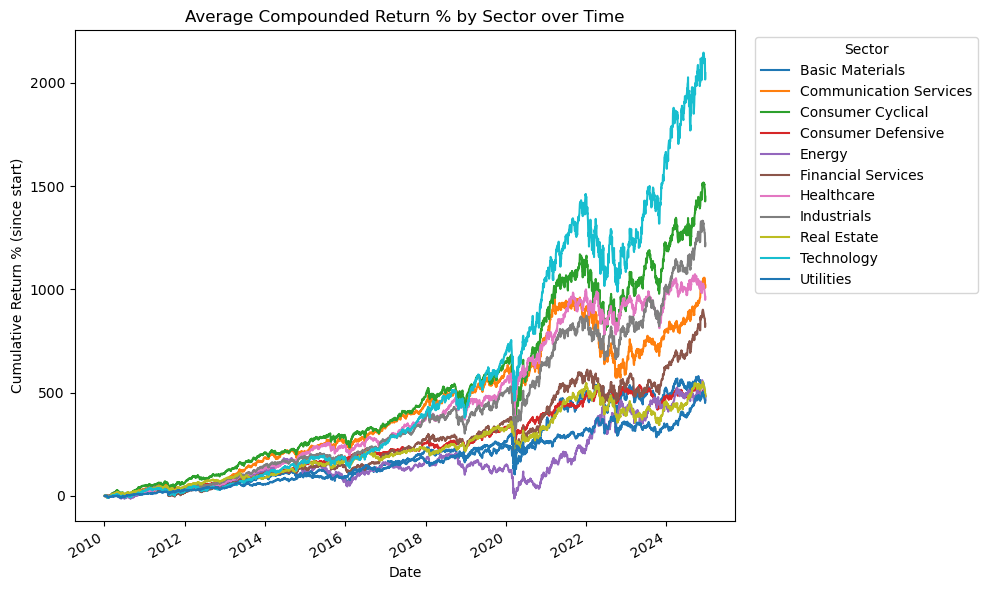

In [358]:
import pandas as pd
import numpy as np

# Let's assume your dataframe is called 'df'
# with columns: Symbol, Sector, Date, Adj Close, Close, High, Low, Open, Volume

# 1) Convert Date to datetime if needed and sort
df_merged['Date'] = pd.to_datetime(df_merged['Date'])
df_merged.sort_values(by=['Symbol', 'Date'], inplace=True)

# 2) Compute daily returns for each symbol
#    groupby('Symbol') ensures we calculate pct_change() for each stock individually
df_merged['daily_return'] = df_merged.groupby('Symbol')['Adj Close'].pct_change()

# 3) Compute average daily return by Sector and Date
#    This yields one average return per sector per day
df_sector_daily = (
    df_merged.groupby(['Date', 'Sector'])['daily_return']
      .mean()
      .reset_index(name='sector_daily_return')
      .dropna(subset=['sector_daily_return'])  # drop rows with NaN returns
)

# 4) Sort by Date so we can do a proper cumulative product
df_sector_daily.sort_values(by=['Sector', 'Date'], inplace=True) 

# 5) For each sector, compound the average daily returns over time
#    We'll pivot so each sector is a column, the index is Date
df_pivot = df_sector_daily.pivot(index='Date', columns='Sector', values='sector_daily_return')

# 6) Calculate the cumulative return over time
#    (1 + daily_return).cumprod() - 1 for each sector
df_cum = ((1 + df_pivot).cumprod() - 1) * 100

plt.figure(figsize=(10, 6))
df_cum.plot(ax=plt.gca())
plt.title("Average Compounded Return % by Sector over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Return % (since start)")
plt.legend(title="Sector", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [331]:
import numpy as np

# Let's pick the final row of df_cum as the end of our data
end_date = df_cum.index[-1]
start_date = df_cum.index[0]

num_days = (end_date - start_date).days
years = num_days / 365.0

final_cum_returns = df_cum.iloc[-1]  # last row of each sector's cumulative return

# annualized return (assuming daily compounding):
# (1 + total_return)^(1/years) - 1
annualized_returns = (((1 + final_cum_returns) ** (1/years)) - 1) * 100

print("Annualized Returns by Sector (simple average daily returns):")
print(annualized_returns.sort_values(ascending=False))

Annualized Returns by Sector (simple average daily returns):
Sector
Technology                22.739438
Consumer Cyclical         20.089071
Industrials               18.830498
Communication Services    17.511415
Healthcare                17.112502
Financial Services        16.095775
Real Estate               12.614405
Consumer Defensive        12.518730
Basic Materials           12.447629
Energy                    12.277213
Utilities                 12.225256
Name: 2024-12-20 00:00:00, dtype: float64


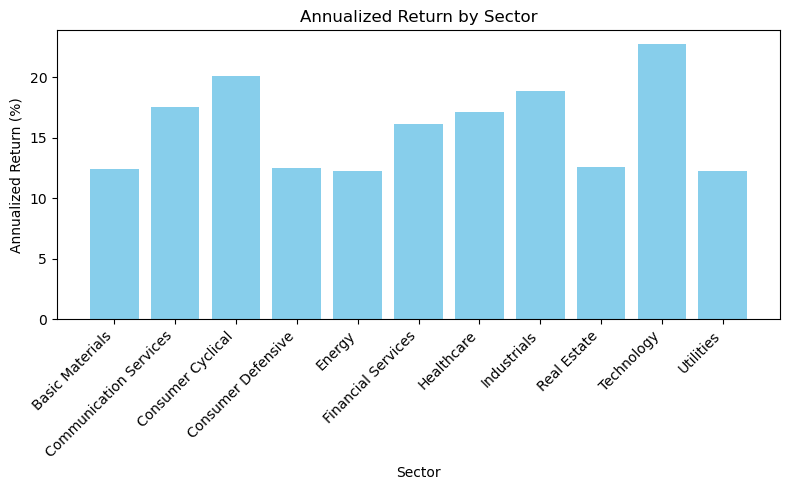

In [344]:
# Convert the Series to a DataFrame for easier plotting
df_annualized = annualized_returns.reset_index()
df_annualized.columns = ['Sector', 'Annualized_Return']

# Multiply by 100 to get percentage values
df_annualized['Annualized_Return'] = df_annualized['Annualized_Return']

# --------------------------------------------------
# Plot a bar chart of annualized returns by sector
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.bar(df_annualized['Sector'], df_annualized['Annualized_Return'], color='skyblue')
plt.title("Annualized Return by Sector")
plt.xlabel("Sector")
plt.ylabel("Annualized Return (%)")
plt.xticks(rotation=45, ha='right')  # rotate sector names if needed
plt.tight_layout()
plt.show()


In [360]:
import pandas as pd

# 2. Sort and set index = 'Date' for resampling
df_merged_2 = df_merged

df_merged_2.sort_values(['Symbol', 'Date'], inplace=True)
df_merged_2.set_index('Date', inplace=True)

# 3a. Resample monthly: get last Close of each month per (Symbol, Sector)
monthly_close = (
    df_merged_2
    .groupby(['Symbol','Sector'])['Close']
    .resample('ME')
    .last()        # use last price in the month
    .dropna()
)

# 3b. Compute monthly returns: [ (Price_t - Price_(t-1)) / Price_(t-1) ]
monthly_returns = monthly_close.groupby(level=['Symbol','Sector']).pct_change() * 100

# 3c. Compute the average monthly return for each Symbol, Sector
avg_monthly_returns = (
    monthly_returns
    .groupby(level=['Symbol','Sector'])
    .mean()
    .reset_index(name='Avg_Monthly_Return')
)


# 4a. Resample yearly: get last Close of each year per (Symbol, Sector)
yearly_close = (
    df_merged
    .groupby(['Symbol','Sector'])['Close']
    .resample('YE')
    .last()
    .dropna()
)

# 4b. Compute yearly returns
yearly_returns = yearly_close.groupby(level=['Symbol','Sector']).pct_change() * 100

# 4c. Average yearly return
avg_yearly_returns = (
    yearly_returns
    .groupby(level=['Symbol','Sector'])
    .mean()
    .reset_index(name='Avg_Yearly_Return')
)


# 5. Merge average monthly & yearly returns into a single table
df_perf = pd.merge(
    avg_monthly_returns, 
    avg_yearly_returns, 
    on=['Symbol','Sector'],
    how='inner'
)


# 6. Pick top 3 performing stocks per sector by Avg_Yearly_Return
top_3_by_sector = (
    df_perf
    .groupby('Sector', group_keys=False)
    .apply(lambda grp: grp.nlargest(3, 'Avg_Yearly_Return'))
    # or use 'Avg_Monthly_Return' if you prefer
)

# 7. Print the result
print(top_3_by_sector)


    Symbol                  Sector  Avg_Monthly_Return  Avg_Yearly_Return
408    SHW         Basic Materials            1.805460          22.847972
420   STLD         Basic Materials            1.662847          19.023536
310    MLM         Basic Materials            1.373157          16.956838
334   NFLX  Communication Services            3.808850          50.055183
305   META  Communication Services            2.587835          43.987014
453   TTWO  Communication Services            2.114811          28.106225
450   TSLA       Consumer Cyclical            4.730177          99.457392
124    CZR       Consumer Cyclical            3.320343          37.284919
32    AMZN       Consumer Cyclical            2.377772          33.711099
423    STZ      Consumer Defensive            1.770003          22.420157
313   MNST      Consumer Defensive            1.871943          22.415851
107   COST      Consumer Defensive            1.725077          21.785034
443    TPL                  Energy    

/var/folders/db/g3_b7s9n3fvdsyb4pfxmnj200000gn/T/ipykernel_24227/3424303255.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: grp.nlargest(3, 'Avg_Yearly_Return'))


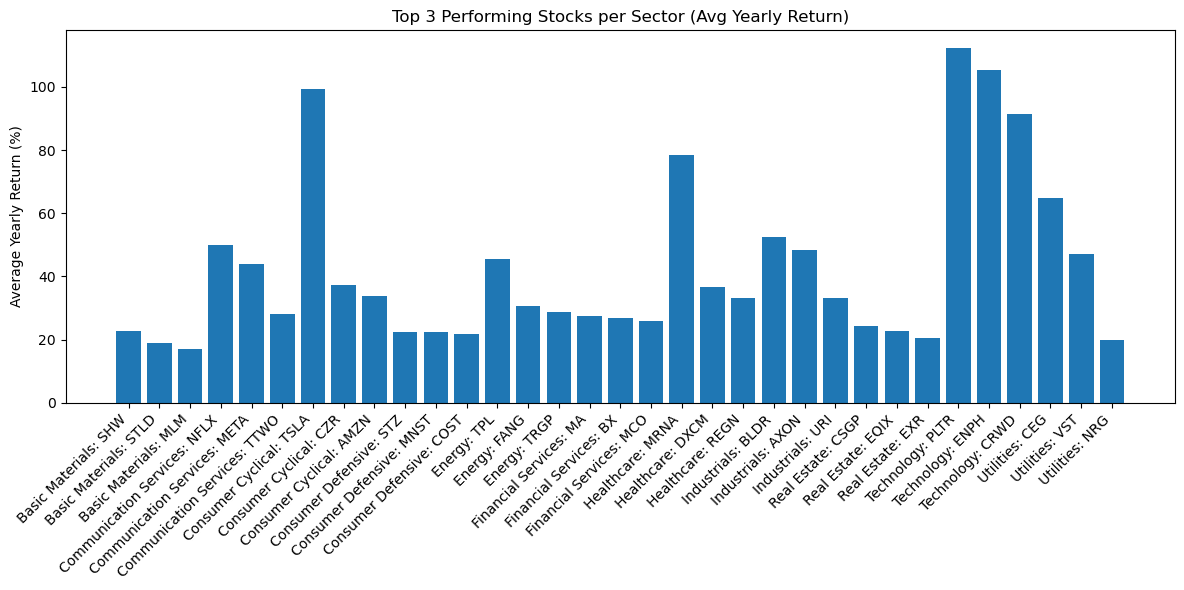

In [362]:
# Sort globally by Avg_Yearly_Return or by (Sector, Avg_Yearly_Return) if preferred
top_3_by_sector_sorted = top_3_by_sector.sort_values(['Sector', 'Avg_Yearly_Return'], ascending=[True, False])

# Create x-axis labels like "Technology: AAPL", "Technology: MSFT", etc.
labels = top_3_by_sector_sorted.apply(
    lambda row: f"{row['Sector']}: {row['Symbol']}", axis=1
)
returns = top_3_by_sector_sorted['Avg_Yearly_Return']  # in %

x = np.arange(len(labels))  # numeric positions

plt.figure(figsize=(12, 6))
plt.bar(x, returns)
plt.xticks(x, labels, rotation=45, ha='right')
plt.title("Top 3 Performing Stocks per Sector (Avg Yearly Return)")
plt.ylabel("Average Yearly Return (%)")
plt.tight_layout()
plt.show()

# 3. Time-series forecast

In [388]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from sklearn.preprocessing import MinMaxScaler

In [392]:
df_cum.sort_index(inplace=True)

sector = "Technology"  # pick a sector
series = df_cum[sector].dropna()  # get just that sector's cumulative returns

values = series.values.reshape(-1, 1)  # shape (T, 1)

df_cum.sort_index(inplace=True)

sector = "Technology"
series = df_cum[sector].dropna()

# Convert to a numpy array
values = series.values.reshape(-1, 1)  # shape (T, 1)

train_size = int(len(values) * 0.8)
train_data = values[:train_size]
test_data  = values[train_size:]

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])      
    return np.array(X), np.array(y)

window_size = 30

# Build training sequences
X_train, y_train = create_sequences(train_scaled, window_size)
X_test,  y_test  = create_sequences(test_scaled,  window_size)


In [394]:
model_lstm = Sequential([
    LSTM(64, return_sequences=False, input_shape=(window_size, 1)),
    Dense(1)
])

model_lstm.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0057 - val_loss: 2.6387e-04
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.5642e-05 - val_loss: 8.6982e-04
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.4791e-05 - val_loss: 2.8021e-04
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.4822e-05 - val_loss: 4.8076e-04
Epoch 5/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.4347e-05 - val_loss: 3.7997e-04
Epoch 6/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.9102e-05 - val_loss: 5.3532e-04
Epoch 7/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.0660e-05 - val_loss: 2.9196e-04
Epoch 8/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.2130e-05 - val_loss: 3.2896e-04
Epoch 9/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.8515e-05 - val_loss: 9.5722e-04
Epoch 10/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.0238e-05 - val_loss: 2.5146e-04
Epoch 11/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.9743e-05 - 

In [396]:
model_gru = Sequential([
    GRU(64, return_sequences=False, input_shape=(window_size, 1)),
    Dense(1)
])

model_gru.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

history_gru = model_gru.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0132 - val_loss: 3.8241e-04
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.5329e-05 - val_loss: 3.1522e-04
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.1817e-05 - val_loss: 1.9413e-04
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.0672e-05 - val_loss: 1.6541e-04
Epoch 5/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.9971e-05 - val_loss: 1.3503e-04
Epoch 6/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2531e-05 - val_loss: 1.5892e-04
Epoch 7/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.5960e-05 - val_loss: 1.2635e-04
Epoch 8/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.4861e-05 - val_loss: 1.7865e-04
Epoch 9/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.5136e-05 - val_loss: 1.9253e-04
Epoch 10/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.1438e-05 - val_loss: 2.1723e-04
Epoch 11/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.0053e-05 - 

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


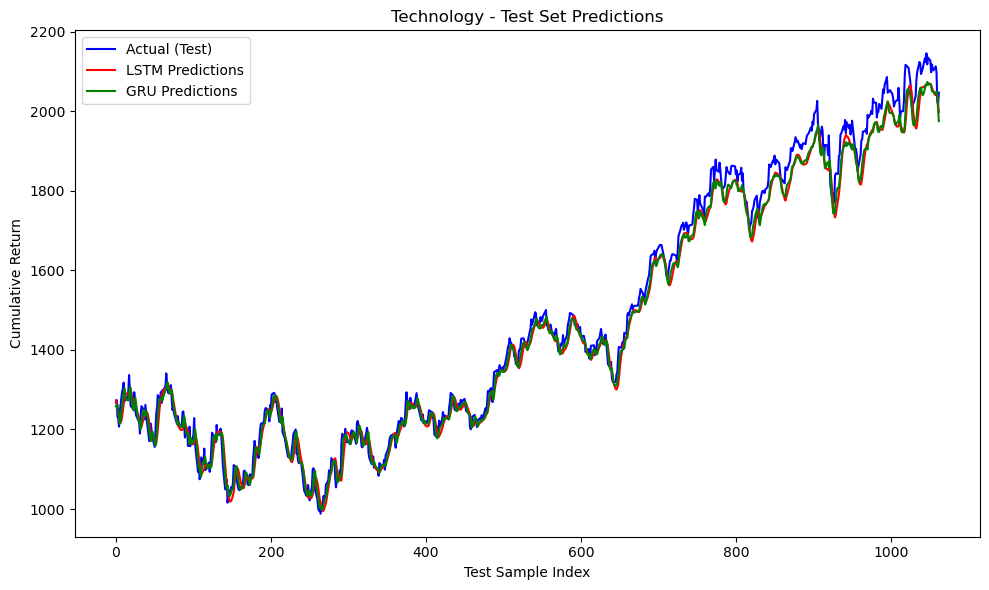

In [398]:
# LSTM predictions
pred_lstm = model_lstm.predict(X_test)

# GRU predictions
pred_gru = model_gru.predict(X_test)

pred_lstm_unscaled = scaler.inverse_transform(pred_lstm)
pred_gru_unscaled  = scaler.inverse_transform(pred_gru)

y_test_unscaled    = scaler.inverse_transform(y_test)

plt.figure(figsize=(10, 6))
plt.plot(y_test_unscaled, label='Actual (Test)', color='blue')
plt.plot(pred_lstm_unscaled, label='LSTM Predictions', color='red')
plt.plot(pred_gru_unscaled,  label='GRU Predictions',  color='green')
plt.title(f"{sector} - Test Set Predictions")
plt.xlabel("Test Sample Index")
plt.ylabel("Cumulative Return")
plt.legend()
plt.tight_layout()
plt.show()


In [411]:
full_scaled = scaler.fit_transform(values)

def forecast_future(model, data_scaled, window_size=30, steps=365):
    data_scaled = data_scaled.copy()
    future_preds = []
    
    # Start with the last `window_size` points
    input_seq = data_scaled[-window_size:].reshape(1, window_size, 1)
    
    for _ in range(steps):
        pred = model.predict(input_seq)  # shape (1,1)
        
        future_preds.append(pred[0, 0])
        
        # Now shift window by 1 step and add the new predicted value at the end
        # input_seq[:, 1:, :] has shape (1, window_size-1, 1)
        # We need new_val to have shape (1, 1, 1)
        new_val = np.array(pred[0, 0]).reshape((1, 1, 1))
        input_seq = np.concatenate([input_seq[:, 1:, :], new_val], axis=1)

    return np.array(future_preds).reshape(-1, 1)


# Forecast 2 years (730 days) with LSTM and GRU
future_lstm_scaled = forecast_future(model_lstm, full_scaled, window_size, steps=730)
future_gru_scaled  = forecast_future(model_gru,  full_scaled, window_size, steps=730)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━

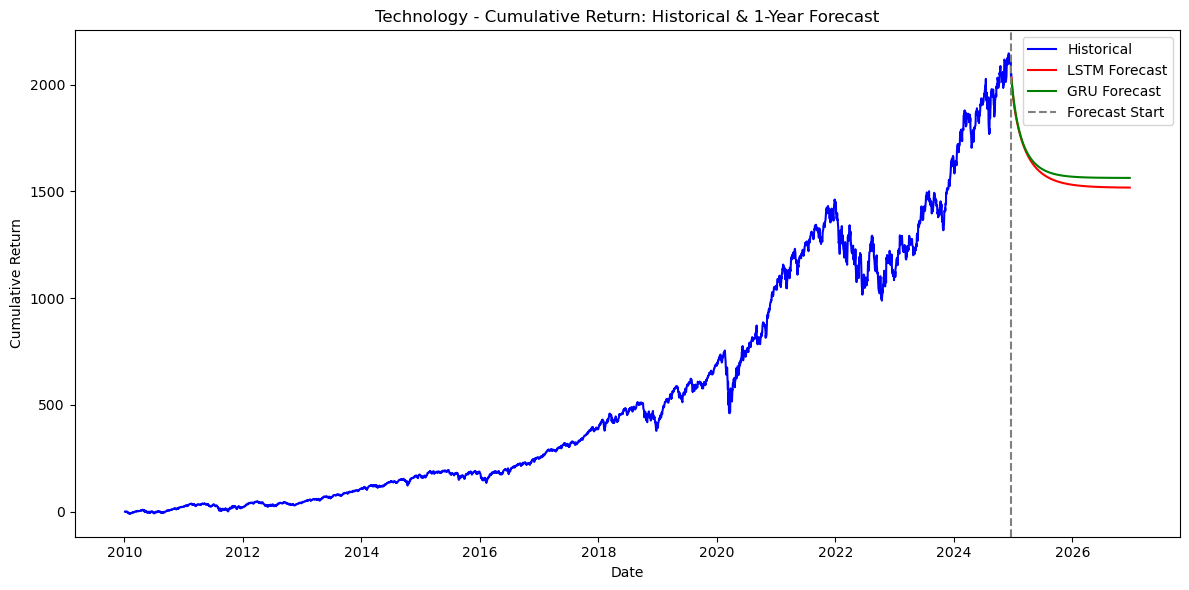

In [415]:
future_lstm = scaler.inverse_transform(future_lstm_scaled)
future_gru  = scaler.inverse_transform(future_gru_scaled)

# Last date in your historical data
last_date = series.index[-1]  # e.g. 2024-10-20

forecast_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=730,
    freq='D'
)

# Convert to a Pandas Series for convenience
future_lstm_series = pd.Series(future_lstm.flatten(), index=forecast_dates, name='LSTM_Forecast')
future_gru_series  = pd.Series(future_gru.flatten(),  index=forecast_dates, name='GRU_Forecast')

plt.figure(figsize=(12, 6))

# Plot historical cumulative returns (entire series)
plt.plot(series.index, series.values, label='Historical', color='blue')

# Plot LSTM forecast
plt.plot(future_lstm_series.index, future_lstm_series.values, label='LSTM Forecast', color='red')

# Plot GRU forecast
plt.plot(future_gru_series.index, future_gru_series.values, label='GRU Forecast', color='green')

plt.axvline(x=last_date, color='gray', linestyle='--', label='Forecast Start')

plt.title(f"{sector} - Cumulative Return: Historical & 1-Year Forecast")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend(loc="best")
plt.tight_layout()
plt.show()
